#  TruthLens AI — Transformer-Based Fake News Detection

This notebook demonstrates an end-to-end NLP classification workflow using **DistilBERT**, **Hugging Face Transformers**, **PyTorch**, and **Scikit-learn**.

**Pipeline:** Dataset → EDA → Train/Validation Split → Tokenization → DistilBERT Fine-tuning → Evaluation → Custom Prediction → Save Model

> **Important:** The small CSV included with the project is only for testing the pipeline. Use a large, properly curated dataset for meaningful model performance.


## 1. Install required libraries


In [ ]:
# Run this once if the packages are not installed.
# In Jupyter:
# %pip install torch transformers datasets accelerate pandas scikit-learn matplotlib


## 2. Import libraries


In [1]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch version: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4


## 3. Load the dataset


In [2]:
DATA_PATH = "/content/drive/MyDrive/news.csv"

df = pd.read_csv(DATA_PATH)
df.head()


,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [3]:
print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nLabel counts:")
print(df["label"].value_counts())


Dataset shape: (6335, 4)

Columns: ['Unnamed: 0', 'title', 'text', 'label']

Missing values:
Unnamed: 0    0
title         0
text          0
label         0
dtype: int64

Label counts:
label
REAL    3171
FAKE    3164
Name: count, dtype: int64


## 4. Basic EDA

Labels used in this project:

- `0` = REAL
- `1` = FAKE


/tmp/ipykernel_1469/1614700427.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.bar(["REAL (0)", "FAKE (1)"], [label_counts.get(0, 0), label_counts.get(1, 0)])


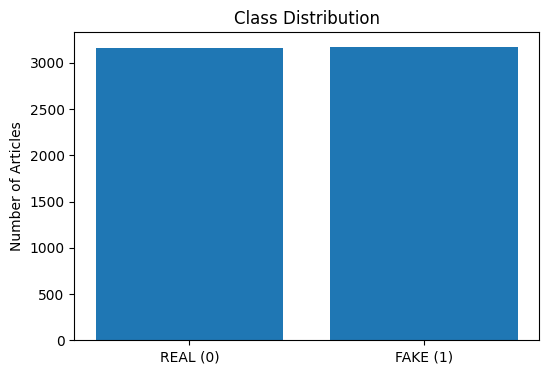

In [4]:
label_counts = df["label"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["REAL (0)", "FAKE (1)"], [label_counts.get(0, 0), label_counts.get(1, 0)])
plt.title("Class Distribution")
plt.ylabel("Number of Articles")
plt.show()


count      6335.000000
mean       4707.250355
std        5090.956446
min           1.000000
25%        1741.500000
50%        3642.000000
75%        6192.000000
max      115372.000000
Name: text_length, dtype: float64


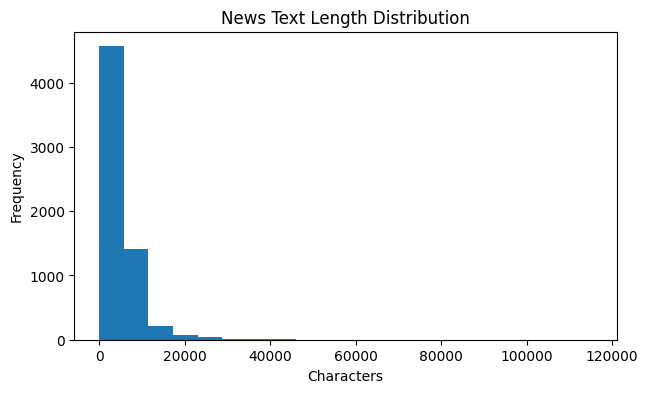

In [5]:
df["text_length"] = df["text"].astype(str).str.len()

print(df["text_length"].describe())

plt.figure(figsize=(7, 4))
plt.hist(df["text_length"], bins=20)
plt.title("News Text Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()


## 5. Prepare and split the data


In [7]:
df = df[["text", "label"]].dropna().copy()

# Convert text column to string
df["text"] = df["text"].astype(str)

# Clean labels
df["label"] = df["label"].astype(str).str.strip().str.upper()

print("Labels before conversion:")
print(df["label"].value_counts())

# Convert REAL/FAKE to numbers
label_mapping = {
    "REAL": 0,
    "FAKE": 1
}

df["label"] = df["label"].map(label_mapping)

# Check for unexpected labels
if df["label"].isna().any():
    print("\nUnknown labels found:")
    print(df.loc[df["label"].isna(), "label"])
    raise ValueError("Dataset contains labels other than REAL and FAKE.")

df["label"] = df["label"].astype(int)

print("\nLabels after conversion:")
print(df["label"].value_counts())

print("\nDataset:")
display(df.head())

Labels before conversion:
label
REAL    3171
FAKE    3164
Name: count, dtype: int64

Labels after conversion:
label
0    3171
1    3164
Name: count, dtype: int64

Dataset:


,text,label
0,"Daniel Greenfield, a Shillman Journalism Fello...",1
1,Google Pinterest Digg Linkedin Reddit Stumbleu...,1
2,U.S. Secretary of State John F. Kerry said Mon...,0
3,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",1
4,It's primary day in New York and front-runners...,0


## 6. Load DistilBERT tokenizer


In [8]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

example = tokenizer(
    "This is an example news article.",
    truncation=True,
    padding="max_length",
    max_length=64,
)

print("Input IDs:", example["input_ids"][:15])
print("Attention mask:", example["attention_mask"][:15])


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Input IDs: [101, 2023, 2003, 2019, 2742, 2739, 3720, 1012, 102, 0, 0, 0, 0, 0, 0]
Attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]


## 7. Convert to Hugging Face datasets and tokenize


In [10]:
train_df, val_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True))

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256,
    )

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)

print(train_dataset)

Map:   0%|          | 0/5068 [00:00<?, ? examples/s]

Map:   0%|          | 0/1267 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5068
})


## 8. Load the Transformer classification model


In [11]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
)

print(model.__class__.__name__)


model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification


## 9. Define evaluation metrics


In [12]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0,
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


## 10. Fine-tune DistilBERT

For the tiny demonstration CSV this only proves that the pipeline works. Replace the dataset with thousands of representative examples before interpreting the metrics.


In [13]:
training_args = TrainingArguments(
    output_dir="training_output",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=10,
    save_strategy="epoch",
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()


Step,Training Loss
10,0.701490
20,0.653666
30,0.580684
40,0.508192
50,0.517184
60,0.524862
70,0.424870
80,0.391069
90,0.197822
100,0.298919


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3801, training_loss=0.11443815910530306, metrics={'train_runtime': 431.7676, 'train_samples_per_second': 35.213, 'train_steps_per_second': 8.803, 'total_flos': 1007017164582912.0, 'train_loss': 0.11443815910530306, 'epoch': 3.0})

## 11. Evaluate the model


In [14]:
evaluation_results = trainer.evaluate()

for key, value in evaluation_results.items():
    print(f"{key}: {value}")


Training Loss,Validation Loss,Step,Accuracy,Precision,Recall,F1
0.000213,0.157156,3801,0.974743,0.983897,0.965245,0.974482


eval_loss: 0.15715596079826355
eval_accuracy: 0.9747434885556433
eval_precision: 0.9838969404186796
eval_recall: 0.9652448657187994
eval_f1: 0.9744816586921851


In [15]:
prediction_output = trainer.predict(val_dataset)
predicted_labels = np.argmax(prediction_output.predictions, axis=-1)
true_labels = prediction_output.label_ids

print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=["REAL", "FAKE"],
        zero_division=0,
    )
)


              precision    recall  f1-score   support

        REAL       0.97      0.98      0.97       634
        FAKE       0.98      0.97      0.97       633

    accuracy                           0.97      1267
   macro avg       0.97      0.97      0.97      1267
weighted avg       0.97      0.97      0.97      1267



## 12. Confusion matrix


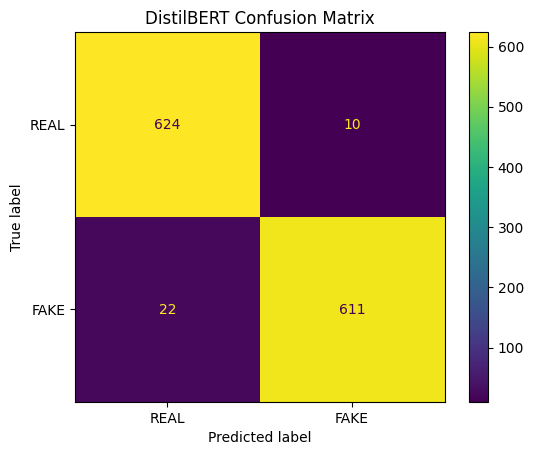

In [16]:
cm = confusion_matrix(true_labels, predicted_labels, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["REAL", "FAKE"],
)

disp.plot()
plt.title("DistilBERT Confusion Matrix")
plt.show()


## 13. Predict custom news


In [17]:
def predict_news(text):
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256,
    )

    device = next(model.parameters()).device
    inputs = {key: value.to(device) for key, value in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(outputs.logits, dim=1)[0].cpu()
    prediction = torch.argmax(probabilities).item()

    return {
        "prediction": "FAKE" if prediction == 1 else "REAL",
        "confidence": float(probabilities[prediction]),
        "real_probability": float(probabilities[0]),
        "fake_probability": float(probabilities[1]),
    }

sample_news = "Government announces a new education program after cabinet approval."
result = predict_news(sample_news)

print("News:", sample_news)
print("Prediction:", result["prediction"])
print(f"Confidence: {result['confidence'] * 100:.2f}%")
print(f"REAL probability: {result['real_probability'] * 100:.2f}%")
print(f"FAKE probability: {result['fake_probability'] * 100:.2f}%")


News: Government announces a new education program after cabinet approval.
Prediction: REAL
Confidence: 99.88%
REAL probability: 99.88%
FAKE probability: 0.12%


In [19]:
sample_news = """
Scientists have discovered a secret planet made entirely of gold
located just 500 kilometers from Earth, and governments around the
world are hiding the discovery from the public.
"""

result = predict_news(sample_news)

print("News:", sample_news)
print("Prediction:", result["prediction"])
print(f"Confidence: {result['confidence'] * 100:.2f}%")
print(f"REAL probability: {result['real_probability'] * 100:.2f}%")
print(f"FAKE probability: {result['fake_probability'] * 100:.2f}%")

News: 
Scientists have discovered a secret planet made entirely of gold
located just 500 kilometers from Earth, and governments around the
world are hiding the discovery from the public.

Prediction: FAKE
Confidence: 99.87%
REAL probability: 0.13%
FAKE probability: 99.87%


## 14. Save the trained model


In [18]:
MODEL_OUTPUT = "model"

os.makedirs(MODEL_OUTPUT, exist_ok=True)

model.save_pretrained(MODEL_OUTPUT)
tokenizer.save_pretrained(MODEL_OUTPUT)

print(f"Model and tokenizer saved to: {MODEL_OUTPUT}")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to: model
